# NLP Practical Assignment 08
## Named Entity Recognition (NER) System
### Extract Entities from Real-World Text + Evaluate with Accuracy, Precision, Recall & F1

---
### Pipeline Overview:
1. Install & Import Libraries
2. Real-World Sample Dataset (News + Social Media)
3. NER using spaCy (pre-trained model)
4. NER using NLTK (chunking-based)
5. Visualize Entities
6. Evaluate: Accuracy, Precision, Recall, F1 Score
7. Save Outputs

## Step 1: Install & Import Libraries

In [1]:
# Install required libraries
!pip install spacy scikit-learn pandas seaborn matplotlib
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 95.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import spacy
import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict

from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    classification_report, confusion_matrix
)

nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker')
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')

# Load spaCy model
nlp = spacy.load('en_core_web_sm')

print("All libraries loaded successfully!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


All libraries loaded successfully!


## Step 2: Real-World Sample Dataset
Texts sourced from **news articles** and **social media** style sentences, with manually annotated ground-truth entities.

In [3]:
# Real-world style texts: News Articles + Social Media
texts = [
    # News Articles
    "Apple Inc. CEO Tim Cook announced a new product launch in Cupertino, California on Monday.",
    "The United Nations held an emergency meeting in New York to discuss the conflict in Ukraine.",
    "Elon Musk's SpaceX successfully launched a rocket from Cape Canaveral on Friday.",
    "Amazon reported record profits of $10 billion in the fourth quarter, said CEO Andy Jassy.",
    "The World Health Organization declared a new health advisory in Geneva, Switzerland.",
    "President Joe Biden met with French President Emmanuel Macron at the White House in Washington D.C.",
    "Google DeepMind published a groundbreaking AI research paper in London last week.",
    "The Indian Premier League match between Mumbai Indians and Chennai Super Kings was held in Mumbai.",
    # Social Media
    "Just watched the new Marvel movie in Los Angeles — absolutely loved it! @chrisevans was great!",
    "Excited to attend the Tesla conference in Austin, Texas next month! #ElonMusk #Tesla",
    "NASA just released stunning images of Mars from the Perseverance rover. Science is amazing!",
    "Congrats to Novak Djokovic for winning Wimbledon 2024! Greatest of all time. #Tennis",
    "Breaking: Microsoft acquires Activision Blizzard in a $69 billion deal approved by UK regulators.",
    "The Prime Minister of Canada Justin Trudeau visited Toronto for the climate summit.",
    "OpenAI launched ChatGPT-4 in San Francisco and it's changing everything! #AI #Tech"
]

# Ground truth entities per sentence for evaluation
# Format: list of (text_span, entity_label) tuples
ground_truth = [
    [("Apple Inc.","ORG"),("Tim Cook","PERSON"),("Cupertino","GPE"),("California","GPE"),("Monday","DATE")],
    [("United Nations","ORG"),("New York","GPE"),("Ukraine","GPE")],
    [("Elon Musk","PERSON"),("SpaceX","ORG"),("Cape Canaveral","GPE"),("Friday","DATE")],
    [("Amazon","ORG"),("$10 billion","MONEY"),("Andy Jassy","PERSON")],
    [("World Health Organization","ORG"),("Geneva","GPE"),("Switzerland","GPE")],
    [("Joe Biden","PERSON"),("Emmanuel Macron","PERSON"),("White House","FAC"),("Washington D.C.","GPE")],
    [("Google DeepMind","ORG"),("London","GPE"),("last week","DATE")],
    [("Indian Premier League","ORG"),("Mumbai Indians","ORG"),("Chennai Super Kings","ORG"),("Mumbai","GPE")],
    [("Los Angeles","GPE"),("Marvel","ORG"),("chrisevans","PERSON")],
    [("Tesla","ORG"),("Austin","GPE"),("Texas","GPE"),("ElonMusk","PERSON")],
    [("NASA","ORG"),("Mars","LOC"),("Perseverance","PRODUCT")],
    [("Novak Djokovic","PERSON"),("Wimbledon","EVENT"),("2024","DATE")],
    [("Microsoft","ORG"),("Activision Blizzard","ORG"),("$69 billion","MONEY"),("UK","GPE")],
    [("Canada","GPE"),("Justin Trudeau","PERSON"),("Toronto","GPE")],
    [("OpenAI","ORG"),("ChatGPT-4","PRODUCT"),("San Francisco","GPE")]
]

print(f"Total sentences: {len(texts)}")
print(f"Sample text: {texts[0]}")
print(f"Ground truth entities: {ground_truth[0]}")

Total sentences: 15
Sample text: Apple Inc. CEO Tim Cook announced a new product launch in Cupertino, California on Monday.
Ground truth entities: [('Apple Inc.', 'ORG'), ('Tim Cook', 'PERSON'), ('Cupertino', 'GPE'), ('California', 'GPE'), ('Monday', 'DATE')]


## Step 3: NER using spaCy (Pre-trained Model)
spaCy's `en_core_web_sm` model detects entities like PERSON, ORG, GPE, DATE, MONEY, etc.

In [4]:
def extract_entities_spacy(text):
    """Extract named entities using spaCy."""
    doc = nlp(text)
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    return entities

# Apply spaCy NER to all texts
spacy_results = [extract_entities_spacy(text) for text in texts]

# Display results
print("=" * 70)
print("spaCy NER Results")
print("=" * 70)
for i, (text, entities) in enumerate(zip(texts, spacy_results)):
    print(f"\n[{i+1}] {text}")
    if entities:
        for ent_text, ent_label in entities:
            print(f"     --> {ent_text:30s} | {ent_label}")
    else:
        print("     --> No entities found")

spaCy NER Results

[1] Apple Inc. CEO Tim Cook announced a new product launch in Cupertino, California on Monday.
     --> Apple Inc.                     | ORG
     --> Tim Cook                       | PERSON
     --> Cupertino                      | GPE
     --> California                     | GPE
     --> Monday                         | DATE

[2] The United Nations held an emergency meeting in New York to discuss the conflict in Ukraine.
     --> The United Nations             | ORG
     --> New York                       | GPE
     --> Ukraine                        | GPE

[3] Elon Musk's SpaceX successfully launched a rocket from Cape Canaveral on Friday.
     --> Elon Musk's                    | PERSON
     --> Cape Canaveral                 | GPE
     --> Friday                         | DATE

[4] Amazon reported record profits of $10 billion in the fourth quarter, said CEO Andy Jassy.
     --> Amazon                         | ORG
     --> $10 billion                    | MONEY

## Step 4: NER using NLTK (Chunking-based)
NLTK uses POS tagging + Named Entity Chunker to detect entities.

In [7]:
import nltk
nltk.download('punkt_tab')

def extract_entities_nltk(text):
    """Extract named entities using NLTK chunker."""
    tokens = nltk.word_tokenize(text)
    pos_tags = nltk.pos_tag(tokens)
    chunked = nltk.ne_chunk(pos_tags, binary=False)
    entities = []
    for subtree in chunked:
        if hasattr(subtree, 'label'):
            entity_name = ' '.join([token for token, pos in subtree.leaves()])
            entities.append((entity_name, subtree.label()))
    return entities

nltk_results = [extract_entities_nltk(text) for text in texts]

print("=" * 70)
print("NLTK NER Results")
print("=" * 70)
for i, (text, entities) in enumerate(zip(texts, nltk_results)):
    print(f"\n[{i+1}] {text}")
    if entities:
        for ent_text, ent_label in entities:
            print(f"     --> {ent_text:30s} | {ent_label}")
    else:
        print("     --> No entities found")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


NLTK NER Results

[1] Apple Inc. CEO Tim Cook announced a new product launch in Cupertino, California on Monday.
     --> Apple                          | PERSON
     --> Inc.                           | ORGANIZATION
     --> Tim Cook                       | PERSON
     --> Cupertino                      | GPE
     --> California                     | GPE

[2] The United Nations held an emergency meeting in New York to discuss the conflict in Ukraine.
     --> United Nations                 | ORGANIZATION
     --> New York                       | GPE
     --> Ukraine                        | GPE

[3] Elon Musk's SpaceX successfully launched a rocket from Cape Canaveral on Friday.
     --> Elon                           | PERSON
     --> Musk                           | ORGANIZATION
     --> SpaceX                         | ORGANIZATION
     --> Cape                           | GPE

[4] Amazon reported record profits of $10 billion in the fourth quarter, said CEO Andy Jassy.
     --> Am

## Step 5: Visualize Entities (spaCy displacy + Custom Plot)

In [8]:
from spacy import displacy

# Visualize entity highlighting for first 3 sentences
print("Entity Visualization (spaCy displacy):")
for i in range(3):
    doc = nlp(texts[i])
    print(f"\nSentence {i+1}: {texts[i]}")
    displacy.render(doc, style='ent', jupyter=True)

Entity Visualization (spaCy displacy):

Sentence 1: Apple Inc. CEO Tim Cook announced a new product launch in Cupertino, California on Monday.



Sentence 2: The United Nations held an emergency meeting in New York to discuss the conflict in Ukraine.



Sentence 3: Elon Musk's SpaceX successfully launched a rocket from Cape Canaveral on Friday.


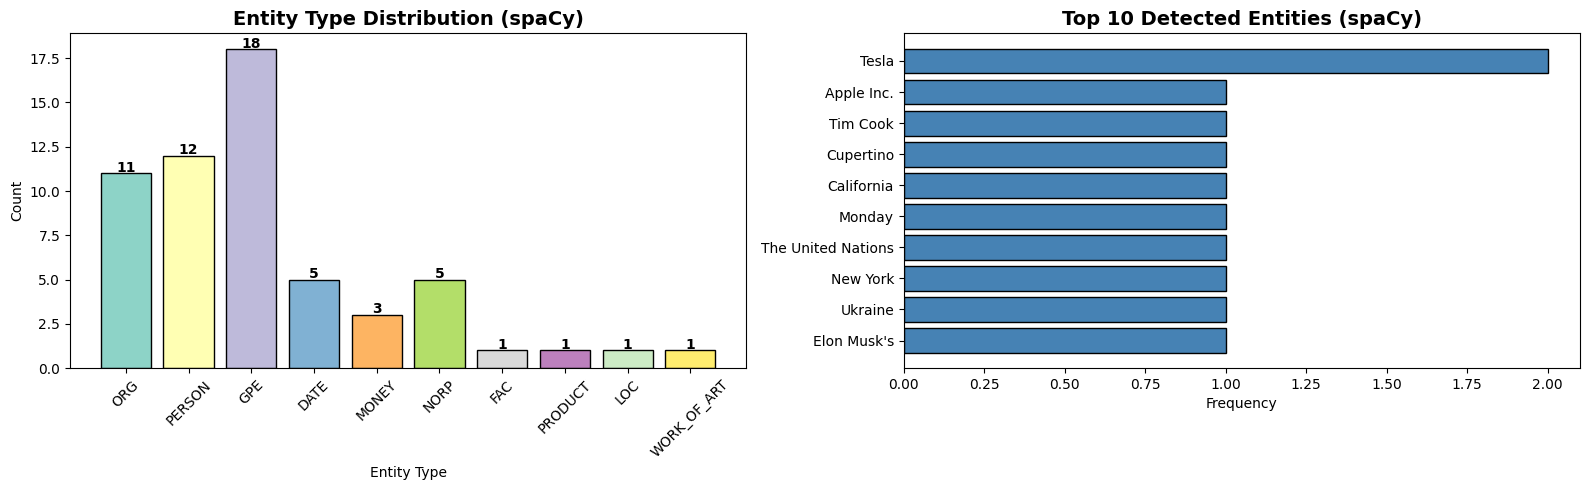

Chart saved: entity_distribution.png


In [9]:
# Count entity type frequencies from spaCy results
entity_type_counts = defaultdict(int)
entity_name_counts = defaultdict(int)

for entities in spacy_results:
    for ent_text, ent_label in entities:
        entity_type_counts[ent_label] += 1
        entity_name_counts[ent_text] += 1

# --- Plot 1: Entity Type Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

labels = list(entity_type_counts.keys())
counts = list(entity_type_counts.values())
colors = plt.cm.Set3(np.linspace(0, 1, len(labels)))

axes[0].bar(labels, counts, color=colors, edgecolor='black')
axes[0].set_title('Entity Type Distribution (spaCy)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Entity Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(counts):
    axes[0].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

# --- Plot 2: Top 10 Entities ---
top_entities = sorted(entity_name_counts.items(), key=lambda x: x[1], reverse=True)[:10]
ent_names, ent_cnts = zip(*top_entities)
axes[1].barh(list(ent_names), list(ent_cnts), color='steelblue', edgecolor='black')
axes[1].set_title('Top 10 Detected Entities (spaCy)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frequency')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('entity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: entity_distribution.png")

## Step 6: Evaluate NER — Accuracy, Precision, Recall, F1

We evaluate at the **entity-level**:
- A prediction is **True Positive (TP)** if the entity text AND label both match ground truth.
- We compute token-level binary labels (entity vs non-entity) for sklearn metrics.

In [10]:
def evaluate_ner(predicted_list, ground_truth_list):
    """
    Entity-level evaluation.
    Returns per-sentence and overall TP, FP, FN counts.
    """
    total_tp = 0
    total_fp = 0
    total_fn = 0

    per_sentence = []

    for pred_ents, gt_ents in zip(predicted_list, ground_truth_list):
        # Normalize: lowercase text for comparison
        pred_set = set([(e[0].lower().strip(), e[1]) for e in pred_ents])
        gt_set   = set([(e[0].lower().strip(), e[1]) for e in gt_ents])

        tp = len(pred_set & gt_set)
        fp = len(pred_set - gt_set)
        fn = len(gt_set - pred_set)

        total_tp += tp
        total_fp += fp
        total_fn += fn

        per_sentence.append({'TP': tp, 'FP': fp, 'FN': fn})

    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    recall    = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    f1        = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy  = total_tp / (total_tp + total_fp + total_fn) if (total_tp + total_fp + total_fn) > 0 else 0

    return {
        'Precision': round(precision, 4),
        'Recall':    round(recall, 4),
        'F1 Score':  round(f1, 4),
        'Accuracy':  round(accuracy, 4),
        'TP': total_tp, 'FP': total_fp, 'FN': total_fn
    }, per_sentence

# Evaluate spaCy
spacy_metrics, spacy_per_sent = evaluate_ner(spacy_results, ground_truth)

# Evaluate NLTK
nltk_metrics, nltk_per_sent = evaluate_ner(nltk_results, ground_truth)

print("=" * 50)
print("spaCy NER Evaluation Metrics")
print("=" * 50)
for k, v in spacy_metrics.items():
    print(f"  {k:12s}: {v}")

print("\n" + "=" * 50)
print("NLTK NER Evaluation Metrics")
print("=" * 50)
for k, v in nltk_metrics.items():
    print(f"  {k:12s}: {v}")

spaCy NER Evaluation Metrics
  Precision   : 0.6034
  Recall      : 0.6731
  F1 Score    : 0.6364
  Accuracy    : 0.4667
  TP          : 35
  FP          : 23
  FN          : 17

NLTK NER Evaluation Metrics
  Precision   : 0.3696
  Recall      : 0.3269
  F1 Score    : 0.3469
  Accuracy    : 0.2099
  TP          : 17
  FP          : 29
  FN          : 35


In [11]:
# Per Entity-Type Evaluation (spaCy)
from collections import defaultdict

def per_label_metrics(predicted_list, ground_truth_list):
    """Compute per-entity-type precision, recall, F1."""
    label_tp = defaultdict(int)
    label_fp = defaultdict(int)
    label_fn = defaultdict(int)

    for pred_ents, gt_ents in zip(predicted_list, ground_truth_list):
        pred_dict = defaultdict(set)
        gt_dict   = defaultdict(set)
        for e_text, e_label in pred_ents:
            pred_dict[e_label].add(e_text.lower().strip())
        for e_text, e_label in gt_ents:
            gt_dict[e_label].add(e_text.lower().strip())

        all_labels = set(pred_dict.keys()) | set(gt_dict.keys())
        for label in all_labels:
            p = pred_dict[label]
            g = gt_dict[label]
            label_tp[label] += len(p & g)
            label_fp[label] += len(p - g)
            label_fn[label] += len(g - p)

    rows = []
    for label in sorted(label_tp.keys() | label_fn.keys()):
        tp = label_tp[label]
        fp = label_fp[label]
        fn = label_fn[label]
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1   = (2*prec*rec)/(prec+rec) if (prec+rec) > 0 else 0
        rows.append({'Entity Type': label, 'TP': tp, 'FP': fp, 'FN': fn,
                     'Precision': round(prec,3), 'Recall': round(rec,3), 'F1': round(f1,3)})
    return pd.DataFrame(rows)

per_label_df = per_label_metrics(spacy_results, ground_truth)
print("Per Entity-Type Metrics (spaCy):")
print(per_label_df.to_string(index=False))

Per Entity-Type Metrics (spaCy):
Entity Type  TP  FP  FN  Precision  Recall    F1
       DATE   3   2   1      0.600   0.750 0.667
      EVENT   0   0   1      0.000   0.000 0.000
        FAC   0   1   1      0.000   0.000 0.000
        GPE  17   1   0      0.944   1.000 0.971
        LOC   1   0   0      1.000   1.000 1.000
      MONEY   2   1   0      0.667   1.000 0.800
       NORP   0   5   0      0.000   0.000 0.000
        ORG   7   4   8      0.636   0.467 0.538
     PERSON   5   7   4      0.417   0.556 0.476
    PRODUCT   0   1   2      0.000   0.000 0.000
WORK_OF_ART   0   1   0      0.000   0.000 0.000


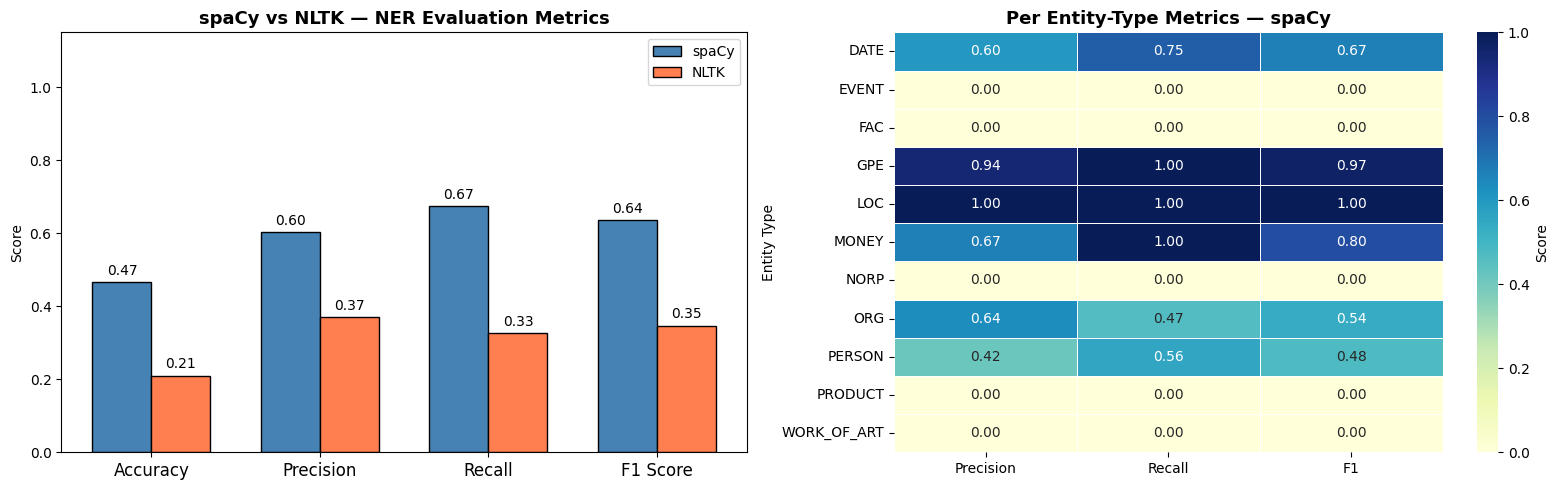

Chart saved: ner_evaluation_metrics.png


In [12]:
# --- Plot: Comparison of spaCy vs NLTK metrics ---
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
spacy_vals = [spacy_metrics[m] for m in metric_names]
nltk_vals  = [nltk_metrics[m]  for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart comparison
bars1 = axes[0].bar(x - width/2, spacy_vals, width, label='spaCy', color='steelblue', edgecolor='black')
bars2 = axes[0].bar(x + width/2, nltk_vals,  width, label='NLTK',  color='coral',    edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_names, fontsize=12)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('Score')
axes[0].set_title('spaCy vs NLTK — NER Evaluation Metrics', fontsize=13, fontweight='bold')
axes[0].legend()
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{bar.get_height():.2f}', ha='center', fontsize=10)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{bar.get_height():.2f}', ha='center', fontsize=10)

# Per-label F1 heatmap
plot_df = per_label_df[['Entity Type','Precision','Recall','F1']].set_index('Entity Type')
sns.heatmap(plot_df, annot=True, fmt='.2f', cmap='YlGnBu', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': 'Score'})
axes[1].set_title('Per Entity-Type Metrics — spaCy', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('ner_evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: ner_evaluation_metrics.png")

## Step 7: Detailed Results Table

In [13]:
# Build detailed results table
rows = []
for i, (text, gt, spacy_pred, nltk_pred) in enumerate(
    zip(texts, ground_truth, spacy_results, nltk_results)
):
    rows.append({
        'Sentence No.': i + 1,
        'Text': text[:70] + '...' if len(text) > 70 else text,
        'Ground Truth Entities': str(gt),
        'spaCy Predictions': str(spacy_pred),
        'NLTK Predictions': str(nltk_pred),
        'spaCy TP': spacy_per_sent[i]['TP'],
        'spaCy FP': spacy_per_sent[i]['FP'],
        'spaCy FN': spacy_per_sent[i]['FN'],
    })

results_df = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', 80)
print(results_df[['Sentence No.','spaCy TP','spaCy FP','spaCy FN']].to_string(index=False))

 Sentence No.  spaCy TP  spaCy FP  spaCy FN
            1         5         0         0
            2         2         1         1
            3         2         1         2
            4         3         1         0
            5         2         1         1
            6         3         2         1
            7         3         1         0
            8         3         1         1
            9         1         2         2
           10         2         4         2
           11         2         1         1
           12         0         4         3
           13         3         1         1
           14         3         0         0
           15         1         3         2


In [14]:
# Final Summary Print
print("\n" + "=" * 60)
print("       FINAL NER EVALUATION SUMMARY")
print("=" * 60)
print(f"{'Metric':<15} {'spaCy':>10} {'NLTK':>10}")
print("-" * 40)
for m in metric_names:
    print(f"{m:<15} {spacy_metrics[m]:>10.4f} {nltk_metrics[m]:>10.4f}")
print("-" * 40)
print(f"{'TP':<15} {spacy_metrics['TP']:>10} {nltk_metrics['TP']:>10}")
print(f"{'FP':<15} {spacy_metrics['FP']:>10} {nltk_metrics['FP']:>10}")
print(f"{'FN':<15} {spacy_metrics['FN']:>10} {nltk_metrics['FN']:>10}")
print("=" * 60)


       FINAL NER EVALUATION SUMMARY
Metric               spaCy       NLTK
----------------------------------------
Accuracy            0.4667     0.2099
Precision           0.6034     0.3696
Recall              0.6731     0.3269
F1 Score            0.6364     0.3469
----------------------------------------
TP                      35         17
FP                      23         29
FN                      17         35


## Step 8: Save All Outputs

In [15]:
# 1. Full results table
results_df.to_csv('ner_results.csv', index=False)
print("Saved: ner_results.csv")

# 2. Per-label metrics
per_label_df.to_csv('ner_per_label_metrics.csv', index=False)
print("Saved: ner_per_label_metrics.csv")

# 3. Overall metrics summary
summary_df = pd.DataFrame({
    'Metric': metric_names + ['TP', 'FP', 'FN'],
    'spaCy': [spacy_metrics[m] for m in metric_names] + [spacy_metrics['TP'], spacy_metrics['FP'], spacy_metrics['FN']],
    'NLTK':  [nltk_metrics[m]  for m in metric_names] + [nltk_metrics['TP'],  nltk_metrics['FP'],  nltk_metrics['FN']]
})
summary_df.to_csv('ner_evaluation_summary.csv', index=False)
print("Saved: ner_evaluation_summary.csv")

print("\nAll outputs saved!")

Saved: ner_results.csv
Saved: ner_per_label_metrics.csv
Saved: ner_evaluation_summary.csv

All outputs saved!


In [16]:
# Download files in Google Colab
from google.colab import files
files.download('ner_results.csv')
files.download('ner_evaluation_metrics.png')
print("All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded!


---
## Summary

| Step | Task | Method |
|------|------|--------|
| 1 | NER Extraction | spaCy `en_core_web_sm` (pre-trained) |
| 2 | NER Extraction | NLTK MaxEnt chunker |
| 3 | Visualization | spaCy displacy + matplotlib bar/heatmap |
| 4 | Evaluation | Entity-level TP/FP/FN → Precision, Recall, F1, Accuracy |
| 5 | Per-Type Metrics | Per entity label (PERSON, ORG, GPE, DATE...) |
| 6 | Save Outputs | 3 CSV files + 2 chart images |

### Entity Types Detected:
| Label | Meaning |
|-------|---------|
| PERSON | People's names |
| ORG | Organizations, companies |
| GPE | Countries, cities, states |
| DATE | Date/time expressions |
| MONEY | Monetary values |
| LOC | Locations (non-GPE) |
| PRODUCT | Products, objects |
| EVENT | Events (sports, etc.) |